<a href="https://colab.research.google.com/github/iMba-I/Labs/blob/main/Lab3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Класс нейронной сети


In [46]:
import numpy as np
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

np.random.seed(42)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(x):
    return np.maximum(0, x)

def softmax(z):
    exp = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

def activation_fun(x, act_type='relu'):
    if act_type == 'relu':
        return relu(x)
    elif act_type == 'sigmoid':
        return sigmoid(x)
    elif act_type == 'softmax':
        return softmax(x)
    else:
        raise ValueError(f"Unknown activation type: {act_type}")

class NeuralNetwork:
    def __init__(self, input_size, architecture, output_size=1, classif_type='bin'):
        self.classif_type = classif_type
        layer_sizes = [input_size] + architecture + [output_size]
        self.L = len(layer_sizes) - 1

        self.weights = []
        self.biases = []
        for i in range(self.L):
            W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(W)
            self.biases.append(b)

        # Для мониторинга
        self.train_loss = []
        self.val_loss = []
        self.test_loss = []
        self.test_acc = []
        self.train_acc = []
        self.val_acc = []
        self.y_pred_check =[]

    def forward(self, X):
        activations = [X]
        zs = []
        A = X
        for i in range(self.L):
            Z = A @ self.weights[i] + self.biases[i]
            zs.append(Z)
            if i != self.L - 1:
                A = activation_fun(Z, 'relu')
            else:
                if self.classif_type == 'bin':
                    A = activation_fun(Z, 'sigmoid')
                else:
                    A = activation_fun(Z, 'softmax')
            activations.append(A)
        return A, zs, activations

    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        if self.classif_type == 'bin':

            eps = 1e-15
            y_pred = np.clip(y_pred, eps, 1 - eps)
            loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        else:

            eps = 1e-15
            y_pred = np.clip(y_pred, eps, 1 - eps)
            loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
        return loss

    def backward(self, y_true, zs, activations):
        m = y_true.shape[0]

        grads_W = [None] * self.L
        grads_b = [None] * self.L

        A_final = activations[-1]

        if self.classif_type == 'bin':
            y_true = y_true.reshape(-1, 1)
            dZ = A_final - y_true
        else:
            dZ = A_final - y_true

        for i in reversed(range(self.L)):
            A_prev = activations[i]
            grads_W[i] = (A_prev.T @ dZ) / m
            grads_b[i] = np.sum(dZ, axis=0, keepdims=True) / m
            if i > 0:
                dA_prev = dZ @ self.weights[i].T
                Z_prev = zs[i-1]
                dZ = dA_prev * (Z_prev > 0)  # relu derivative

        return grads_W, grads_b

    def update_params(self, grads_W, grads_b, lr):
        for i in range(self.L):
            self.weights[i] -= lr * grads_W[i]
            self.biases[i]  -= lr * grads_b[i]

    def predict(self, X):
        y_pred, _, _ = self.forward(X)
        if self.classif_type == 'bin':
            return (y_pred > 0.5).astype(int).ravel()
        else:
            return np.argmax(y_pred, axis=1)

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    def fit(self, X_train, y_train, X_val, y_val, X_test, y_test,
            lr=0.01, epochs=100, batch_size=32):

        m = X_train.shape[0]

        for epoch in range(1, epochs + 1):
            perm = np.random.permutation(m)
            X_shuffled = X_train[perm]
            y_shuffled = y_train[perm]

            for start in range(0, m, batch_size):
                end = min(start + batch_size, m)
                xb = X_shuffled[start:end]
                yb = y_shuffled[start:end]

                y_pred, zs, activations = self.forward(xb)
                grads_W, grads_b = self.backward(yb, zs, activations)
                self.update_params(grads_W, grads_b, lr)

            # ---------------- TRAIN METRICS ----------------
            y_train_pred_prob, _, _ = self.forward(X_train)
            train_loss = self.compute_loss(y_train, y_train_pred_prob)
            y_train_pred = self.predict(X_train)

            if self.classif_type == 'bin':
                train_acc = accuracy_score(y_train, y_train_pred)
            else:
                train_acc = accuracy_score(np.argmax(y_train, axis=1), y_train_pred)

            # ---------------- VAL METRICS ----------------
            y_val_pred_prob, _, _ = self.forward(X_val)
            val_loss = self.compute_loss(y_val, y_val_pred_prob)
            y_val_pred = self.predict(X_val)

            if self.classif_type == 'bin':
                val_acc = accuracy_score(y_val, y_val_pred)
            else:
                val_acc = accuracy_score(np.argmax(y_val, axis=1), y_val_pred)

            # ---------------- TEST METRICS ----------------
            y_test_pred_prob, _, _ = self.forward(X_test)

            self.y_pred_check.append(y_test_pred_prob)
            test_loss = self.compute_loss(y_test, y_test_pred_prob)
            y_test_pred = self.predict(X_test)

            if self.classif_type == 'bin':
                test_acc = accuracy_score(y_test, y_test_pred)
                test_precision = precision_score(y_test, y_test_pred)
                test_recall = recall_score(y_test, y_test_pred)
                test_f1 = f1_score(y_test, y_test_pred)
            else:
                y_test_true = np.argmax(y_test, axis=1)
                test_acc = accuracy_score(y_test_true, y_test_pred)
                test_precision = precision_score(y_test_true, y_test_pred, average='macro')
                test_recall = recall_score(y_test_true, y_test_pred, average='macro')
                test_f1 = f1_score(y_test_true, y_test_pred, average='macro')

            # Save history
            self.train_loss.append(train_loss)
            self.val_loss.append(val_loss)
            self.test_loss.append(test_loss)
            self.test_acc.append(test_acc)
            self.train_acc.append(train_acc)
            self.val_acc.append(val_acc)

            # Print every 10 epochs
            if epoch % 10 == 0 or epoch == 1:
                print(f"Epoch {epoch}: "
                      f"Train loss={train_loss:.4f}, Val loss={val_loss:.4f}, "
                      f"Train acc={train_acc:.4f}, Val acc={val_acc:.4f} | "
                      f"Test loss={test_loss:.4f}, Test acc={test_acc:.4f}, "
                      f"P={test_precision:.4f}, R={test_recall:.4f}, F1={test_f1:.4f}")




Загрузка данных, бинарная классификация



In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Создание и обучение модели

In [ ]:
nn_bin = NeuralNetwork(input_size=X_train.shape[1], architecture=[16, 8], output_size=1, classif_type='bin')
nn_bin.fit(X_train, y_train, X_val, y_val, X_test, y_test, lr=0.01, epochs=1000, batch_size=32)

Визуализация


Train shape: (398, 30), Val shape: (114, 30), Test shape: (57, 30)
Epoch 1: Train loss=0.6911, Val loss=0.6912, Train acc=0.6281, Val acc=0.6228 | Test loss=0.6911, Test acc=0.6316, P=0.6316, R=1.0000, F1=0.7742
Epoch 10: Train loss=0.6773, Val loss=0.6780, Train acc=0.6281, Val acc=0.6228 | Test loss=0.6768, Test acc=0.6316, P=0.6316, R=1.0000, F1=0.7742
Epoch 20: Train loss=0.6691, Val loss=0.6704, Train acc=0.6281, Val acc=0.6228 | Test loss=0.6682, Test acc=0.6316, P=0.6316, R=1.0000, F1=0.7742
Epoch 30: Train loss=0.6649, Val loss=0.6666, Train acc=0.6281, Val acc=0.6228 | Test loss=0.6638, Test acc=0.6316, P=0.6316, R=1.0000, F1=0.7742
Epoch 40: Train loss=0.6627, Val loss=0.6646, Train acc=0.6281, Val acc=0.6228 | Test loss=0.6614, Test acc=0.6316, P=0.6316, R=1.0000, F1=0.7742
Epoch 50: Train loss=0.6614, Val loss=0.6636, Train acc=0.6281, Val acc=0.6228 | Test loss=0.6600, Test acc=0.6316, P=0.6316, R=1.0000, F1=0.7742
Epoch 60: Train loss=0.6608, Val loss=0.6631, Train acc=0.

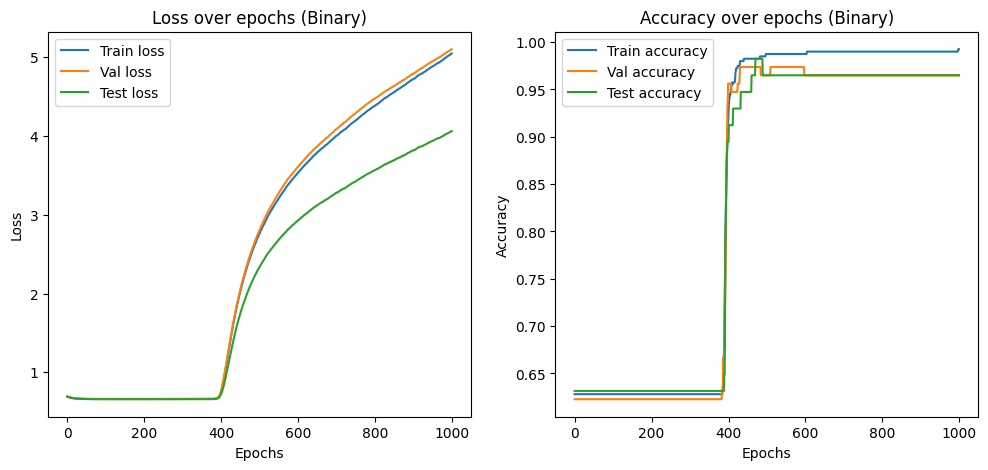

[1 0 1 0 1 1 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 0 0 0 1 1 1 0
 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 0 0 0]


In [47]:

# Графики
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(nn_bin.train_loss, label='Train loss')
plt.plot(nn_bin.val_loss, label='Val loss')
plt.plot(nn_bin.test_loss, label='Test loss')
plt.title("Loss over epochs (Binary)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(nn_bin.train_acc, label='Train accuracy')
plt.plot(nn_bin.val_acc, label='Val accuracy')
plt.plot(nn_bin.test_acc, label='Test accuracy')
plt.title("Accuracy over epochs (Binary)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

print(y_test)

Загрузка и подготовка данных, мультиклассовая классификация



In [48]:
data = load_iris()
X, y = data.data, data.target.reshape(-1, 1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

X_train, X_temp, y_train, y_temp = train_test_split(X, y_onehot, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42, stratify=np.argmax(y_temp, axis=1))

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (105, 4), Val shape: (30, 4), Test shape: (15, 4)


Инициализация и обучение модели (мультиклассовая)


In [49]:
nn_multi = NeuralNetwork(input_size=X_train.shape[1], architecture=[32, 16], output_size=3, classif_type='multi')
nn_multi.fit(X_train, y_train, X_val, y_val, X_test, y_test, lr=0.01, epochs=1000, batch_size=16)

Epoch 1: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667
Epoch 10: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667
Epoch 20: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Epoch 30: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667
Epoch 40: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667
Epoch 50: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Epoch 60: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667
Epoch 70: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667
Epoch 80: Train loss=1.0986, Val loss=1.0986, Train acc=0.3333, Val acc=0.3333 | Test loss=1.0986, Test acc=0.3333, P=0.1111, R=0.3333, F1=0.1667


...

Epoch 720: Train loss=0.9515, Val loss=0.9550, Train acc=0.6667, Val acc=0.6667 | Test loss=0.9543, Test acc=0.6667, P=0.5000, R=0.6667, F1=0.5556
Epoch 730: Train loss=0.8794, Val loss=0.8839, Train acc=0.6667, Val acc=0.6667 | Test loss=0.8839, Test acc=0.6667, P=0.5000, R=0.6667, F1=0.5556
Epoch 740: Train loss=0.7798, Val loss=0.7858, Train acc=0.6667, Val acc=0.6667 | Test loss=0.7866, Test acc=0.6667, P=0.5000, R=0.6667, F1=0.5556


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Epoch 750: Train loss=0.6753, Val loss=0.6825, Train acc=0.6667, Val acc=0.6667 | Test loss=0.6840, Test acc=0.6667, P=0.5000, R=0.6667, F1=0.5556
Epoch 760: Train loss=0.5960, Val loss=0.6044, Train acc=0.6667, Val acc=0.6667 | Test loss=0.6061, Test acc=0.6667, P=0.5000, R=0.6667, F1=0.5556
Epoch 770: Train loss=0.5455, Val loss=0.5550, Train acc=0.6667, Val acc=0.6667 | Test loss=0.5565, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Epoch 780: Train loss=0.5129, Val loss=0.5235, Train acc=0.6762, Val acc=0.7000 | Test loss=0.5245, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 790: Train loss=0.4898, Val loss=0.5020, Train acc=0.6762, Val acc=0.7000 | Test loss=0.5021, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 800: Train loss=0.4719, Val loss=0.4860, Train acc=0.6762, Val acc=0.7000 | Test loss=0.4850, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 810: Train loss=0.4565, Val loss=0.4731, Train acc=0.7048, Val acc=0.7000 | Test loss=0.4705, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 820: Train loss=0.4424, Val loss=0.4618, Train acc=0.7238, Val acc=0.7000 | Test loss=0.4574, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 830: Train loss=0.4286, Val loss=0.4515, Train acc=0.7619, Val acc=0.7333 | Test loss=0.4447, Test acc=0.7333, P=0.8519, R=0.7333, F1=0.6825
Epoch 840: Train loss=0.4150, Val loss=0.4421, Train acc=0.7619, Val acc=0.7333 | Test loss=0.4320, Test acc=0.7333, P

Визуализация процесса обучения


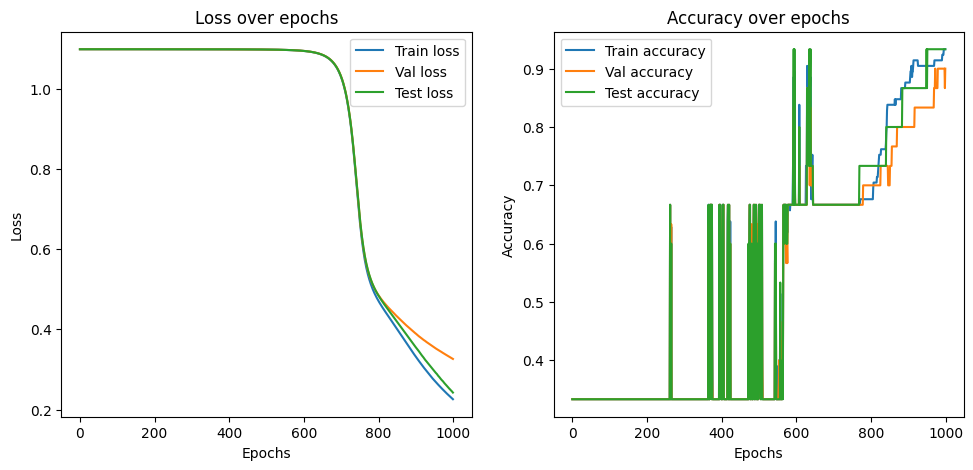

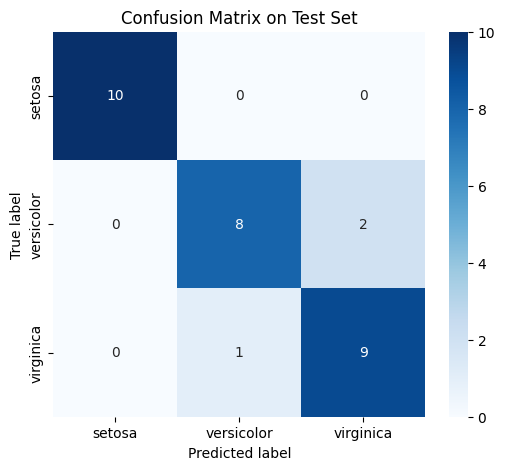

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(nn_multi.train_loss, label='Train loss')
plt.plot(nn_multi.val_loss, label='Val loss')
plt.plot(nn_multi.test_loss, label='Test loss')
plt.title("Loss over epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(nn_multi.train_acc, label='Train accuracy')
plt.plot(nn_multi.val_acc, label='Val accuracy')
plt.plot(nn_multi.test_acc, label='Test accuracy')
plt.title("Accuracy over epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

y_val_pred = nn_multi.predict(X_val)
y_val_true = np.argmax(y_val, axis=1)

# Матрица ошибок
cm = confusion_matrix(y_val_true, y_val_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix on Test Set')
plt.show()

plt.show()

Многоклассовая(данные)


In [51]:
from sklearn.preprocessing import OneHotEncoder



data = load_iris()
X = data.data
y = data.target.reshape(-1, 1)

# One-hot encoding для меток классов
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Делим на train(70%), val(20%), test(10%)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_onehot, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp)

# Создаем и обучаем модель
nn_multi = NeuralNetwork(input_size=X.shape[1], architecture=[16, 8], output_size=3, classif_type='multi')
nn_multi.fit(X_train, y_train, X_val, y_val, lr=0.01, epochs=100, batch_size=16)

# Оценка на тесте
nn_multi.evaluate(X_test, y_test)

# Графики
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(nn_multi.train_loss, label='Train Loss')
plt.plot(nn_multi.val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(nn_multi.train_acc, label='Train Accuracy')
plt.plot(nn_multi.val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



TypeError: NeuralNetwork.fit() missing 2 required positional arguments: 'X_test' and 'y_test'

Многоклассовая(Инициализация)

In [ ]:
nn2 = NeuralNetwork(input_size=4, architecture=[16, 16], output_size=3)
nn2.fit(X_train, y_train, X_val, y_val, lr=0.01, epochs=300, batch_size=16)


Визуализация

In [ ]:
def plot_history(nn):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(nn.train_loss, label="train loss")
    plt.plot(nn.val_loss, label="val loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(nn.train_acc, label="train acc")
    plt.plot(nn.val_acc, label="val acc")
    plt.legend()
    plt.title("Accuracy")

    plt.show()